# PBR Speed and Power Analysis

This notebook compares player weight against football-style Speed Score and max exit velocity. Dominic Santarelli is highlighted in red, while the top performers are labeled for context.

In [14]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_PATH = Path('data/pbr/pbr_2026_draft_board_metrics.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('MLB_DRAFT_ANALYSIS/data/pbr/pbr_2026_draft_board_metrics.csv')

def height_to_inches(x):
    m = re.search(r"(\d+)\s*['-]\s*(\d+)", str(x))
    return int(m.group(1)) * 12 + int(m.group(2)) if m else np.nan

def label_top_and_dominic(ax, data, y_col, top_n=15):
    is_dominic = data['player_name'].str.contains('Dominic Santarelli', case=False, na=False)
    top_labels = data[~is_dominic].nlargest(top_n, y_col)
    for _, row in top_labels.iterrows():
        ax.text(row['weight_lbs'] + 1, row[y_col], row['player_name'], fontsize=8)

    dominic = data[is_dominic]
    for _, row in dominic.iterrows():
        ax.scatter(row['weight_lbs'], row[y_col], s=230, color='red', edgecolor='black', zorder=5)
        ax.text(row['weight_lbs'] + 1, row[y_col], row['player_name'], fontsize=11, weight='bold', color='red')

df = pd.read_csv(DATA_PATH)
df['height_inches'] = df['height'].apply(height_to_inches)
df['weight_lbs'] = pd.to_numeric(df['weight'], errors='coerce')
df['sixty'] = pd.to_numeric(df['sixty_time'], errors='coerce')
df['max_exit_velocity_num'] = pd.to_numeric(df['max_exit_velocity'], errors='coerce')
df['max_hand_speed_num'] = pd.to_numeric(df['max_hand_speed'], errors='coerce')
df['max_bat_speed_num'] = pd.to_numeric(df['max_bat_speed'], errors='coerce')
df['fastball_velocity_num'] = pd.to_numeric(df['fastball_velocity'], errors='coerce')
df['estimated_40'] = df['sixty'] * (40 / 60)
df['speed_score'] = (df['weight_lbs'] * 200) / (df['estimated_40'] ** 4)

df.head()

,rank,player_name,profile_name,profile_url,profile_state,article_position,article_school,article_state,article_notes,high_school,...,home_to_first,height_inches,weight_lbs,sixty,max_exit_velocity_num,max_hand_speed_num,max_bat_speed_num,fastball_velocity_num,estimated_40,speed_score
0,1,Roch Cholowsky,Roch Cholowsky,https://www.prepbaseballreport.com/profiles/AZ...,AZ,SS,UCLA,NaN,+ Outside of SS Roch Cholowsky (UCLA) being th...,UCLA,...,NaN,74.0,190.0,6.94,96.1,22.0,83.9,NaN,4.626667,82.929825
1,2,Justin Lebron,Justin Lebron,https://www.prepbaseballreport.com/profiles/FL...,FL,SS,Alabama,NaN,NaN,Archbishop McCarthy (HS) / FL,...,NaN,73.0,180.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Jacob Lombard,Jacob Lombard,https://www.prepbaseballreport.com/profiles/FL...,FL,SS,Gulliver Prep HS (FL),FL,NaN,Gulliver Prep (HS) / FL,...,NaN,74.0,192.9,NaN,106.8,22.4,81.9,NaN,NaN,NaN
3,4,Tyler Spangler,Tyler Spangler,https://www.prepbaseballreport.com/profiles/CA...,CA,SS,De La Salle HS (CA),CA,NaN,De La Salle (HS) / CA,...,NaN,75.0,190.0,7.25,94.8,NaN,NaN,NaN,4.833333,69.630034
4,5,Carson Bolemon,Carson Bolemon,https://www.prepbaseballreport.com/profiles/SC...,SC,LHP,Southside Christian (SC),SC,NaN,Southside Christian (HS) / SC,...,NaN,74.0,209.4,NaN,NaN,NaN,NaN,95.0,NaN,NaN


## Weight vs Speed Score

Speed Score adjusts sprint performance for body weight. Because PBR provides 60-yard dash times, the 40-yard time here is estimated as `60_time * (40 / 60)`.

In [ ]:
speed_df = df.dropna(subset=['weight_lbs', 'speed_score']).copy()

x = speed_df['weight_lbs']
y = speed_df['speed_score']
weight_mid = x.median()
score_mid = y.median()
slope, intercept = np.polyfit(x, y, 1)
line_x = np.linspace(x.min() - 5, x.max() + 5, 100)
line_y = slope * line_x + intercept

fig, ax = plt.subplots(figsize=(16, 10))
ax.scatter(x, y, s=70, alpha=0.75)
ax.plot(line_x, line_y, color='black', linewidth=2, label='Speed Score trend by weight')
ax.axvline(weight_mid, color='gray', linestyle='--', linewidth=1, label='Median weight')
ax.axhline(score_mid, color='gray', linestyle=':', linewidth=1.5, label='Median Speed Score')

label_top_and_dominic(ax, speed_df, 'speed_score', top_n=15)

ax.text(x.max(), y.max(), 'Heavy + High Speed Score', ha='right', va='top', fontsize=12, weight='bold')
ax.text(x.max(), y.min(), 'Heavy + Low Speed Score', ha='right', va='bottom', fontsize=12, weight='bold')
ax.text(x.min(), y.max(), 'Lighter + High Speed Score', ha='left', va='top', fontsize=12, weight='bold')
ax.text(x.min(), y.min(), 'Lighter + Low Speed Score', ha='left', va='bottom', fontsize=12, weight='bold')

ax.set_title('PBR 2026: Weight vs Football-Style Speed Score')
ax.set_xlabel('Weight (lbs)')
ax.set_ylabel('Speed Score = weight * 200 / estimated_40^4')
ax.legend()
plt.tight_layout()
plt.show()

speed_df.sort_values('speed_score', ascending=False)[['player_name', 'height', 'weight', 'sixty', 'estimated_40', 'speed_score']].head(20)

## Weight vs Max Exit Velocity

This view compares body weight against max exit velocity. The top exit velocity players are labeled, and Dominic Santarelli is highlighted in red.

In [ ]:
ev_df = df.dropna(subset=['weight_lbs', 'max_exit_velocity_num']).copy()

x = ev_df['weight_lbs']
y = ev_df['max_exit_velocity_num']
weight_mid = x.median()
ev_mid = y.median()
slope, intercept = np.polyfit(x, y, 1)
line_x = np.linspace(x.min() - 5, x.max() + 5, 100)
line_y = slope * line_x + intercept

fig, ax = plt.subplots(figsize=(16, 10))
ax.scatter(x, y, s=70, alpha=0.75)
ax.plot(line_x, line_y, color='black', linewidth=2, label='Exit velocity trend by weight')
ax.axvline(weight_mid, color='gray', linestyle='--', linewidth=1, label='Median weight')
ax.axhline(ev_mid, color='gray', linestyle=':', linewidth=1.5, label='Median max EV')

label_top_and_dominic(ax, ev_df, 'max_exit_velocity_num', top_n=15)

ax.text(x.max(), y.max(), 'Heavy + High EV', ha='right', va='top', fontsize=12, weight='bold')
ax.text(x.max(), y.min(), 'Heavy + Low EV', ha='right', va='bottom', fontsize=12, weight='bold')
ax.text(x.min(), y.max(), 'Lighter + High EV', ha='left', va='top', fontsize=12, weight='bold')
ax.text(x.min(), y.min(), 'Lighter + Low EV', ha='left', va='bottom', fontsize=12, weight='bold')

ax.set_title('PBR 2026: Weight vs Max Exit Velocity')
ax.set_xlabel('Weight (lbs)')
ax.set_ylabel('Max exit velocity (mph)')
ax.legend()
plt.tight_layout()
plt.show()

ev_df.sort_values('max_exit_velocity_num', ascending=False)[['player_name', 'height', 'weight', 'max_exit_velocity_num', 'sixty', 'speed_score']].head(20)

## Weight vs Max Hand Speed

This view compares body weight against max hand speed. The top hand speed players are labeled, and Dominic Santarelli is highlighted in red.

In [ ]:
hand_df = df.dropna(subset=['weight_lbs', 'max_hand_speed_num']).copy()

x = hand_df['weight_lbs']
y = hand_df['max_hand_speed_num']
weight_mid = x.median()
hand_mid = y.median()
slope, intercept = np.polyfit(x, y, 1)
line_x = np.linspace(x.min() - 5, x.max() + 5, 100)
line_y = slope * line_x + intercept

fig, ax = plt.subplots(figsize=(16, 10))
ax.scatter(x, y, s=70, alpha=0.75)
ax.plot(line_x, line_y, color='black', linewidth=2, label='Hand speed trend by weight')
ax.axvline(weight_mid, color='gray', linestyle='--', linewidth=1, label='Median weight')
ax.axhline(hand_mid, color='gray', linestyle=':', linewidth=1.5, label='Median max hand speed')

label_top_and_dominic(ax, hand_df, 'max_hand_speed_num', top_n=15)

ax.text(x.max(), y.max(), 'Heavy + High Hand Speed', ha='right', va='top', fontsize=12, weight='bold')
ax.text(x.max(), y.min(), 'Heavy + Low Hand Speed', ha='right', va='bottom', fontsize=12, weight='bold')
ax.text(x.min(), y.max(), 'Lighter + High Hand Speed', ha='left', va='top', fontsize=12, weight='bold')
ax.text(x.min(), y.min(), 'Lighter + Low Hand Speed', ha='left', va='bottom', fontsize=12, weight='bold')

ax.set_title('PBR 2026: Weight vs Max Hand Speed')
ax.set_xlabel('Weight (lbs)')
ax.set_ylabel('Max hand speed')
ax.legend()
plt.tight_layout()
plt.show()

hand_df.sort_values('max_hand_speed_num', ascending=False)[['player_name', 'height', 'weight', 'max_hand_speed_num', 'max_exit_velocity_num', 'sixty', 'speed_score']].head(20)

## Overall Speed/Power Quadrant

This section uses Speed Score and max exit velocity as the two main axes. The overall score is a simple average percentile across available position-player metrics, used only to label the top performers.

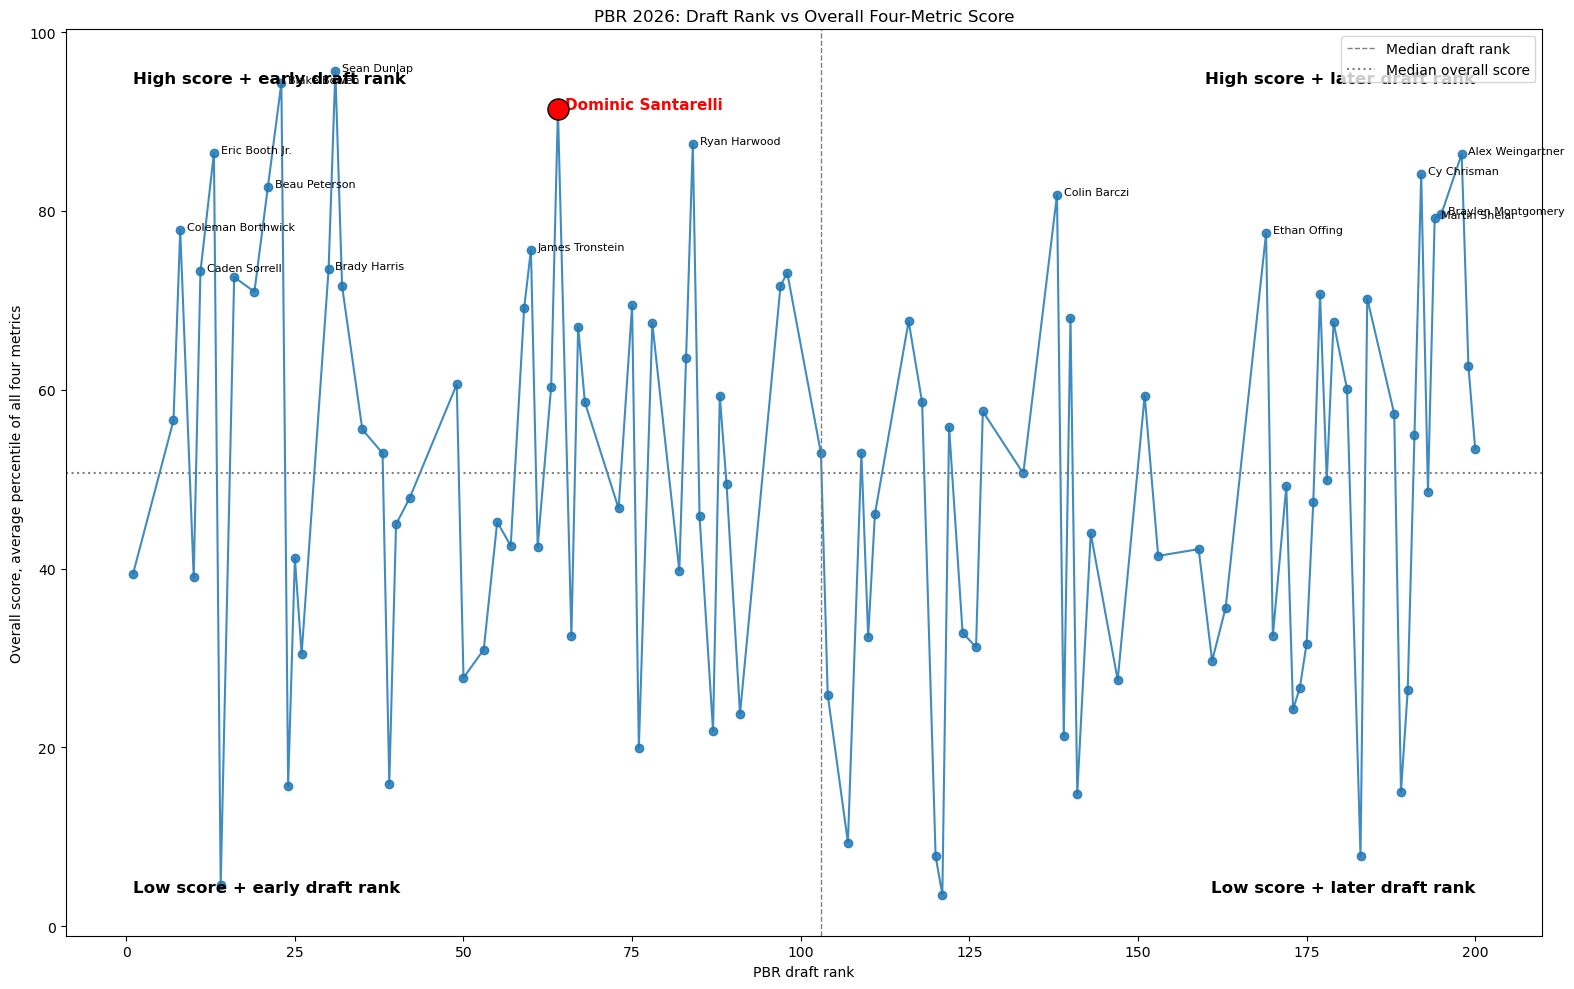

,overall_rank,rank,player_name,height,weight,metrics_available,overall_score,speed_score,max_exit_velocity_num,max_hand_speed_num,max_bat_speed_num,sixty
15,1,31,Sean Dunlap,"6' 3""",203.7,4,95.707071,115.540072,109.8,27.0,88.9,6.50
10,2,23,Blake Bowen,"6' 2""",216.0,4,94.318182,130.355358,107.4,26.4,89.6,6.40
31,3,64,Dominic Santarelli,"6' 1""",224.0,4,91.414141,112.549570,110.1,27.4,83.1,6.70
41,4,84,Ryan Harwood,"6' 2""",218.0,4,87.500000,110.191236,104.1,26.5,87.6,6.69
5,5,13,Eric Booth Jr.,"5' 11""",218.7,4,86.489899,145.118822,105.0,24.6,89.8,6.25
96,6,198,Alex Weingartner,"6' 0""",196.9,4,86.363636,131.492926,107.5,24.9,82.2,6.24
92,7,192,Cy Chrisman,"6' 4""",215.0,4,84.090909,92.236408,106.1,27.5,89.9,6.97
9,8,21,Beau Peterson,"6' 2""",206.0,4,82.702020,102.889764,107.8,24.6,85.0,6.71
64,9,138,Colin Barczi,"6' 2""",220.0,4,81.818182,111.202165,104.0,26.4,81.4,6.69
95,10,195,Braylen Montgomery,"6' 3""",217.5,4,79.671717,119.643496,107.3,24.7,80.4,6.55


In [ ]:
metric_cols = ['speed_score', 'max_exit_velocity_num', 'max_hand_speed_num', 'max_bat_speed_num']
overall_df = df.dropna(subset=['rank'] + metric_cols).copy()
overall_df['rank'] = pd.to_numeric(overall_df['rank'], errors='coerce')
overall_df = overall_df.dropna(subset=['rank']).copy()

percentile_cols = []
for col in metric_cols:
    overall_df[f'{col}_pct'] = overall_df[col].rank(pct=True)
    percentile_cols.append(f'{col}_pct')

overall_df['metrics_available'] = len(metric_cols)
overall_df['overall_score'] = overall_df[percentile_cols].mean(axis=1) * 100
overall_df['overall_rank'] = overall_df['overall_score'].rank(ascending=False, method='min').astype(int)

overall_df = overall_df.sort_values('rank').reset_index(drop=True)

x = overall_df['rank']
y = overall_df['overall_score']
draft_rank_mid = x.median()
score_mid = y.median()

fig, ax = plt.subplots(figsize=(16, 10))
ax.scatter(x, y, s=70, alpha=0.85)
slope, intercept = np.polyfit(x, y, 1)
line_x = np.linspace(x.min(), x.max(), 100)
line_y = slope * line_x + intercept
ax.plot(line_x, line_y, color='black', linewidth=2, label='Overall score trend by draft rank')
ax.axvline(draft_rank_mid, color='gray', linestyle='--', linewidth=1, label='Median draft rank')
ax.axhline(score_mid, color='gray', linestyle=':', linewidth=1.5, label='Median overall score')

is_dominic = overall_df['player_name'].str.contains('Dominic Santarelli', case=False, na=False)
top_overall = overall_df[~is_dominic].nlargest(15, 'overall_score')
for _, row in top_overall.iterrows():
    ax.text(row['rank'] + 1, row['overall_score'], row['player_name'], fontsize=8)

for _, row in overall_df[is_dominic].iterrows():
    ax.scatter(row['rank'], row['overall_score'], s=230, color='red', edgecolor='black', zorder=5)
    ax.text(row['rank'] + 1, row['overall_score'], row['player_name'], fontsize=11, weight='bold', color='red')

ax.text(x.min(), y.max(), 'High score + early draft rank', ha='left', va='top', fontsize=12, weight='bold')
ax.text(x.max(), y.max(), 'High score + later draft rank', ha='right', va='top', fontsize=12, weight='bold')
ax.text(x.min(), y.min(), 'Low score + early draft rank', ha='left', va='bottom', fontsize=12, weight='bold')
ax.text(x.max(), y.min(), 'Low score + later draft rank', ha='right', va='bottom', fontsize=12, weight='bold')

ax.set_title('PBR 2026: Draft Rank vs Overall Four-Metric Score')
ax.set_xlabel('PBR draft rank')
ax.set_ylabel('Overall score, average percentile of all four metrics')
ax.legend()
plt.tight_layout()
plt.show()

overall_df.sort_values('overall_score', ascending=False)[['overall_rank', 'rank', 'player_name', 'height', 'weight', 'metrics_available', 'overall_score', 'speed_score', 'max_exit_velocity_num', 'max_hand_speed_num', 'max_bat_speed_num', 'sixty']].head(25)